# Data Preparation - Exploration stage (5 points)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse

In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dummy-advertising-and-sales-data/Dummy Data HSS.csv


In [22]:
df = pd.read_csv('/kaggle/input/dummy-advertising-and-sales-data/Dummy Data HSS.csv')
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


### Replace missing values

In [24]:
df = df.fillna(df.mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4572 non-null   float64
 1   Radio         4572 non-null   float64
 2   Social Media  4572 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4572 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


### One-hot encoding

In [25]:
df = pd.get_dummies(df)

After data cleaning, the dataset contains the required variables in a format suitable for further regression analysis.

In [26]:
df.head()

,TV,Radio,Social Media,Sales,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,54.732757,0,1,0,0
1,13.0,9.237765,2.409567,46.677897,0,1,0,0
2,41.0,15.886446,2.913410,150.177829,0,1,0,0
3,83.0,30.020028,6.922304,298.246340,0,1,0,0
4,15.0,8.437408,1.405998,56.594181,0,0,1,0


### Correlation

In [27]:
df = df[['TV', 'Radio', 'Social Media', 'Influencer_Macro',
       'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano', 'Sales']]
df.corr()

,TV,Radio,Social Media,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano,Sales
TV,1.000000,0.866885,0.527010,0.021335,-0.012630,-0.004863,-0.003645,0.996652
Radio,0.866885,1.000000,0.606793,0.009518,-0.005071,0.004212,-0.008601,0.867369
Social Media,0.527010,0.606793,1.000000,0.011631,0.013072,-0.013312,-0.011351,0.528121
Influencer_Macro,0.021335,0.009518,0.011631,1.000000,-0.332131,-0.331171,-0.328482,0.019267
Influencer_Mega,-0.012630,-0.005071,0.013072,-0.332131,1.000000,-0.338211,-0.335465,-0.011701
Influencer_Micro,-0.004863,0.004212,-0.013312,-0.331171,-0.338211,1.000000,-0.334495,-0.004099
Influencer_Nano,-0.003645,-0.008601,-0.011351,-0.328482,-0.335465,-0.334495,1.000000,-0.003289
Sales,0.996652,0.867369,0.528121,0.019267,-0.011701,-0.004099,-0.003289,1.000000


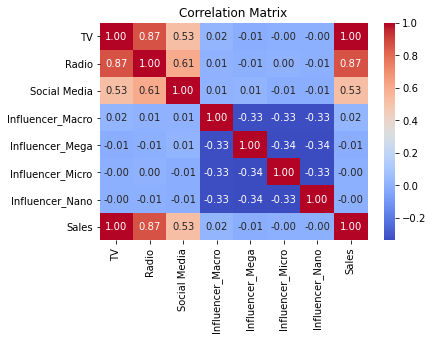

In [28]:
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

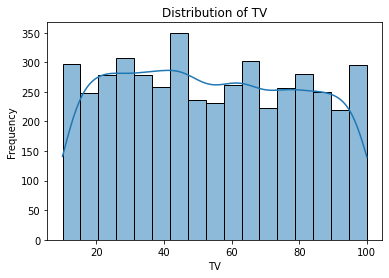

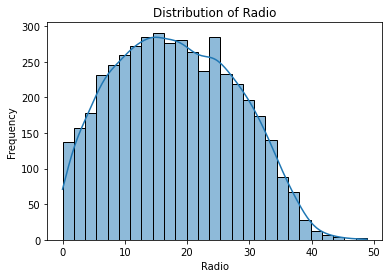

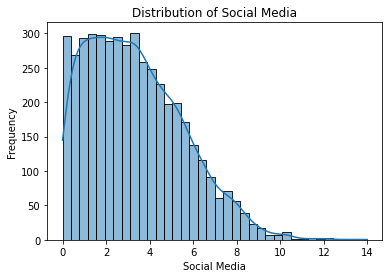

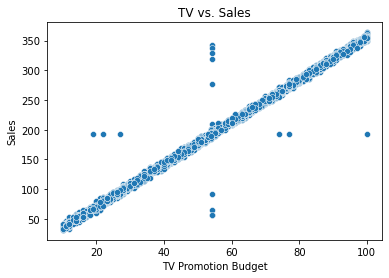

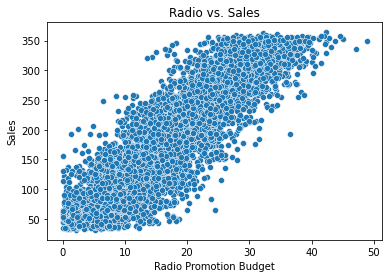

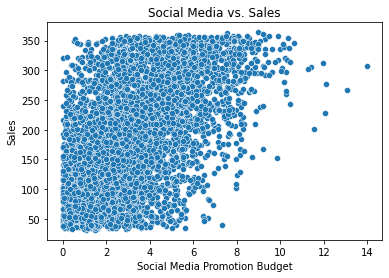

In [29]:
import seaborn as sns

for col in df.columns[:-5]:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

for col in df.columns[:-5]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='Sales')
    plt.title(f'{col} vs. Sales')
    plt.xlabel(f'{col} Promotion Budget')
    plt.ylabel('Sales')
    plt.show()

I selected a correlation heatmap and scatter plots to examine the relationships between marketing expenditures and sales. TV and Radio expenditures show very strong positive correlations with sales, while Social Media expenditure also has a positive correlation, suggesting that these variables may be useful predictors of sales. The scatter plots of Sales against TV and Radio show an approximately linear pattern, which supports the use of linear regression. 

The influencer categories (Mega, Micro, and Nano) show negative correlations with sales. The histograms indicate that Radio and Social Media expenditures are approximately normally distributed. 

# Regression Analysis - Execution stage (4 points)

Based on the exploratory analysis, TV and Radio expenditures show strong approximately linear relationships with sales, while other variables may have nonlinear relationships or interactions. 

I selected Linear Regression as a baseline model and Decision Tree Regression and Random Forest Regression as alternative models that can capture nonlinear patterns. 

I split the dataset into training and testing sets so that the models could be evaluated on unseen data. The same training and testing sets were used for all three models to ensure a fair comparison.

In [30]:
# split the dataset into training and testing sets so that the models could be evaluated on unseen data
x = df.iloc[:,0:-1].values
y = df.iloc[:,-1:].values
x_train, x_test, y_train, y_test = train_test_split(x, y)

### Linear Regression

In [31]:
# Train and evaluate the Linear Regression model
lr_regressor = LinearRegression()
lr_regressor.fit(x_train, y_train)

# Generate predictions for the test set
y_pred_lr = lr_regressor.predict(x_test)

# Evaluate model performance
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", mse(y_test, y_pred_lr) ** 0.5)

0.9940499551253479
7.170589515997947


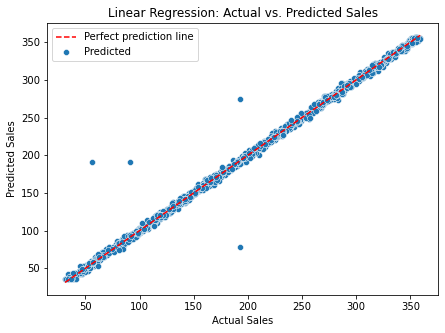

In [62]:
plt.figure(figsize=(7, 5))

sns.scatterplot(x=y_test[:,0], y=y_pred_lr[:,0], label="Predicted")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='red',
    label='Perfect prediction line'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.title('Linear Regression: Actual vs. Predicted Sales')
plt.show()

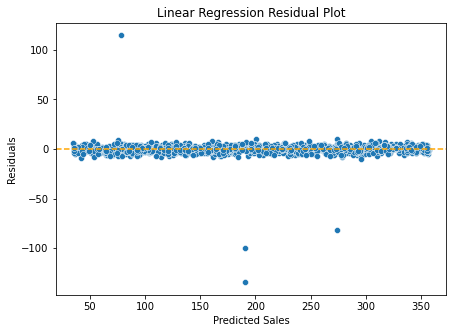

In [59]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred_lr[:,0], y=residuals_lr[:,0])

plt.axhline(0, linestyle='--', color='orange')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Linear Regression Residual Plot')
plt.show()

The scatter plot of linear regression model predicted sales and real sales look good. The residual constantly small, although there are four outliers.

In [32]:
print(lr_regressor.coef_, lr_regressor.intercept_)

[[ 3.50942082  0.1291527   0.09308419 -0.31225063  0.0659685   0.06212082
   0.18416131]] [0.15386497]


Linear Regression offers a model that Sales = 3.50 TV + 0.12 Radio + 0.09 Social Media - 0.31 Macro + 0.06 Mega + 0.06 Micro + 0.18 Nano + 0.15

### Decision Tree

In [35]:
# Train and evaluate the Decision Tree Regression model
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(x_train, y_train)

# Generate predictions for the test set
y_pred_dt = dt_regressor.predict(x_test)

# Evaluate model performance
print("Decision Tree R²:", r2_score(y_test, y_pred_dt))
print("Decision Tree RMSE:", mse(y_test, y_pred_dt) ** 0.5)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  


0.9948977256399986
6.64013096490791


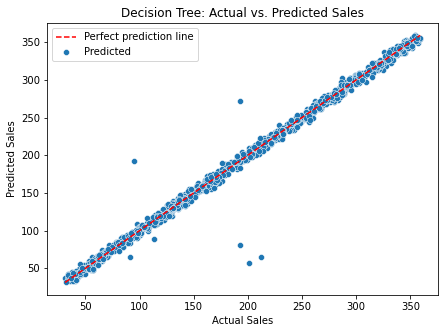

In [69]:
plt.figure(figsize=(7, 5))

sns.scatterplot(x=y_test[:,0], y=y_pred_dt, label="Predicted")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='red',
    label='Perfect prediction line'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.title('Decision Tree: Actual vs. Predicted Sales')
plt.show()

The scatter plot of decision tree model predicted sales and real sales look good. The predicted value are constantly close to the perfect prediction line (actual sales), although there are some outliers.

### Random Forest

In [36]:
# Train and evaluate the Random Forest Regression model
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(x_train, y_train)

# Generate predictions for the test set
y_pred_rf = rf_regressor.predict(x_test)

# Evaluate model performance
print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", mse(y_test, y_pred_rf) ** 0.5)

0.9905009726803292
9.06012750425455


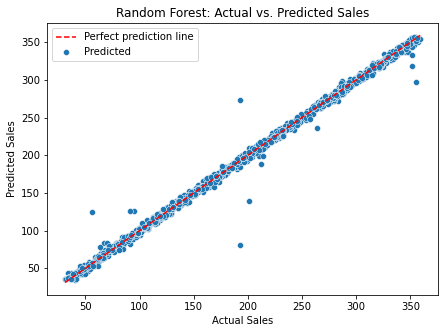

In [70]:
plt.figure(figsize=(7, 5))

sns.scatterplot(x=y_test[:,0], y=y_pred_rf, label="Predicted")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='red',
    label='Perfect prediction line'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.title('Random Forest: Actual vs. Predicted Sales')
plt.show()

The scatter plot of random forest model predicted sales and real sales look good. The predicted value are constantly close to the perfect prediction line (actual sales). The outliers are also closer to the perfect prediction line, compared to linear regression and decision tree.

# Summative Report - Communication stage (3 points)

In [39]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ],
    'RMSE': [
        mse(y_test, y_pred_lr) ** 0.5,
        mse(y_test, y_pred_dt) ** 0.5,
        mse(y_test, y_pred_rf) ** 0.5
    ]
})

results

,Model,R²,RMSE
0,Linear Regression,0.994050,7.170590
1,Decision Tree,0.990501,9.060128
2,Random Forest,0.994898,6.640131
